# QFT Walkthrough

This notebook runs locally with Qiskit's built-in simulator and shows a QFT circuit, its transpiled form, measurement counts, and step-by-step statevector evolution.

## Setup

In VS Code or Antigravity, pick the `quantum-computing` kernel when prompted.

In [1]:
from math import pi

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

NUM_QUBITS = 4
SHOTS = 1024

In [2]:
qc = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
qc.x(0)
qc.append(QFTGate(NUM_QUBITS), range(NUM_QUBITS))
qc.measure(range(NUM_QUBITS), range(NUM_QUBITS))

qc

In [3]:
print(qc.draw(output='text'))

     ┌───┐┌──────┐┌─┐         
q_0: ┤ X ├┤0     ├┤M├─────────
     └───┘│      │└╥┘┌─┐      
q_1: ─────┤1     ├─╫─┤M├──────
          │  Qft │ ║ └╥┘┌─┐   
q_2: ─────┤2     ├─╫──╫─┤M├───
          │      │ ║  ║ └╥┘┌─┐
q_3: ─────┤3     ├─╫──╫──╫─┤M├
          └──────┘ ║  ║  ║ └╥┘
c: 4/══════════════╩══╩══╩══╩═
                   0  1  2  3 


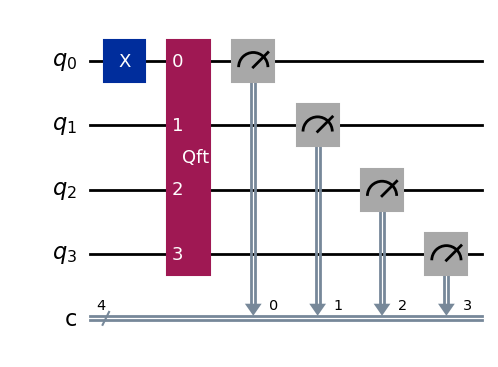

In [4]:
qc.draw(output='mpl', fold=-1)

In [5]:
backend = BasicSimulator()
compiled = transpile(qc, backend)
compiled

In [6]:
result = backend.run(compiled, shots=SHOTS).result()
counts = result.get_counts()
counts

{'1110': 59,
 '0101': 57,
 '1111': 64,
 '0111': 67,
 '1001': 70,
 '1000': 59,
 '0110': 62,
 '0100': 66,
 '0011': 77,
 '0000': 67,
 '1010': 52,
 '1101': 59,
 '1011': 68,
 '1100': 60,
 '0010': 66,
 '0001': 71}

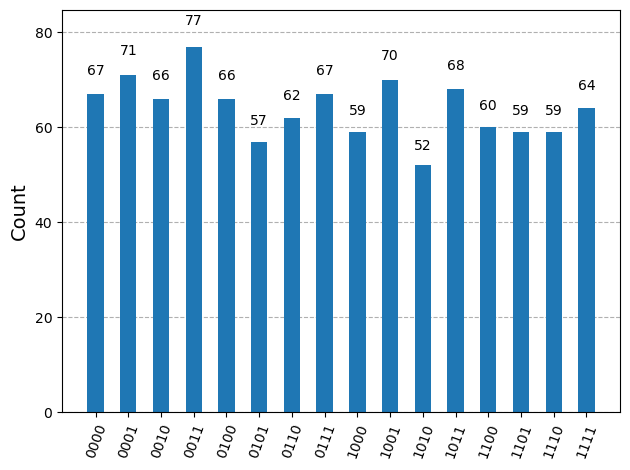

In [7]:
plot_histogram(counts)

## Step-by-step state evolution

This section decomposes the QFT block into simpler gates and shows the statevector after each one. That is the closest notebook view to Quirk-style "watch the process" behavior.

In [7]:
prep = QuantumCircuit(NUM_QUBITS)
prep.x(0)

qft_only = QuantumCircuit(NUM_QUBITS)
qft_only.append(QFTGate(NUM_QUBITS), range(NUM_QUBITS))
qft_steps = qft_only.decompose(reps=10)

state = Statevector.from_instruction(prep)
print('Initial prepared state:')
display(state.draw('latex'))

for index, instruction in enumerate(qft_steps.data, start=1):
    gate = instruction.operation
    qubits = [qft_steps.find_bit(qubit).index for qubit in instruction.qubits]

    step_circuit = QuantumCircuit(NUM_QUBITS)
    step_circuit.append(gate, qubits)
    state = state.evolve(step_circuit)

    print(f'Step {index}: {gate.name} on qubits {qubits}')
    display(state.draw('latex'))

Initial prepared state:


<IPython.core.display.Latex object>

Step 1: u on qubits [3]


<IPython.core.display.Latex object>

Step 2: u on qubits [3]


...

<IPython.core.display.Latex object>

Step 39: cx on qubits [3, 0]


<IPython.core.display.Latex object>

Step 40: cx on qubits [0, 3]


<IPython.core.display.Latex object>